In [9]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

In [10]:
class BrainTumorDataset(Dataset):
    def __init__(self, img_paths, mask_paths, augment=False, img_size=128):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.img_size   = img_size
        self.augment    = augment

        self.aug_transforms = A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.1, scale_limit=0.1,
                rotate_limit=15, p=0.4,
                border_mode=0
            ),
            A.ElasticTransform(alpha=120, sigma=120*0.05, p=0.2),
            A.RandomBrightnessContrast(
                brightness_limit=0.2,
                contrast_limit=0.2, p=0.4
            ),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
            ToTensorV2()
        ])

        self.basic_transforms = A.Compose([
            A.Resize(img_size, img_size),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img  = np.array(
            Image.open(self.img_paths[idx]).convert('L'),
            dtype=np.float32
        )
        mask = np.array(
            Image.open(self.mask_paths[idx]).convert('L'),
            dtype=np.float32
        )

        img = img / 255.0

        mask_bin = np.zeros_like(mask, dtype=np.int64)
        mask_bin[mask > 127] = 1

        if self.augment:
            aug = self.aug_transforms(
                image=img,
                mask=mask_bin.astype(np.float32)
            )
        else:
            aug = self.basic_transforms(
                image=img,
                mask=mask_bin.astype(np.float32)
            )

        return aug['image'].float(), aug['mask'].long()

In [12]:
# Load test split
test_df = pd.read_csv(r'C:\Users\Ismail\Documents\medical-segmentation\data\splits\test.csv')

IMG_SIZE    = 128    # ← must match what you used in training
NUM_WORKERS = 0

test_dataset = BrainTumorDataset(
    test_df['image'].tolist(),
    test_df['mask'].tolist(),
    augment  = False,
    img_size = IMG_SIZE
)

print(f"✅ Test dataset loaded: {len(test_dataset)} samples")

✅ Test dataset loaded: 460 samples


C:\Users\Ismail\anaconda3\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\Ismail\AppData\Local\Temp\ipykernel_14976\792784903.py:23: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = smp.Unet(
    encoder_name    = "mobilenet_v2",  # ← must match training
    encoder_weights = None,
    in_channels     = 1,
    classes         = 2,
    activation      = None
)
model.load_state_dict(
    torch.load(
        'outputs/checkpoints/best_model.pth',
        map_location=device
    )
)
model = model.to(device)
model.eval()
print("✅ Model loaded!")

✅ Model loaded!


✅ Saved to outputs/predictions/results.png


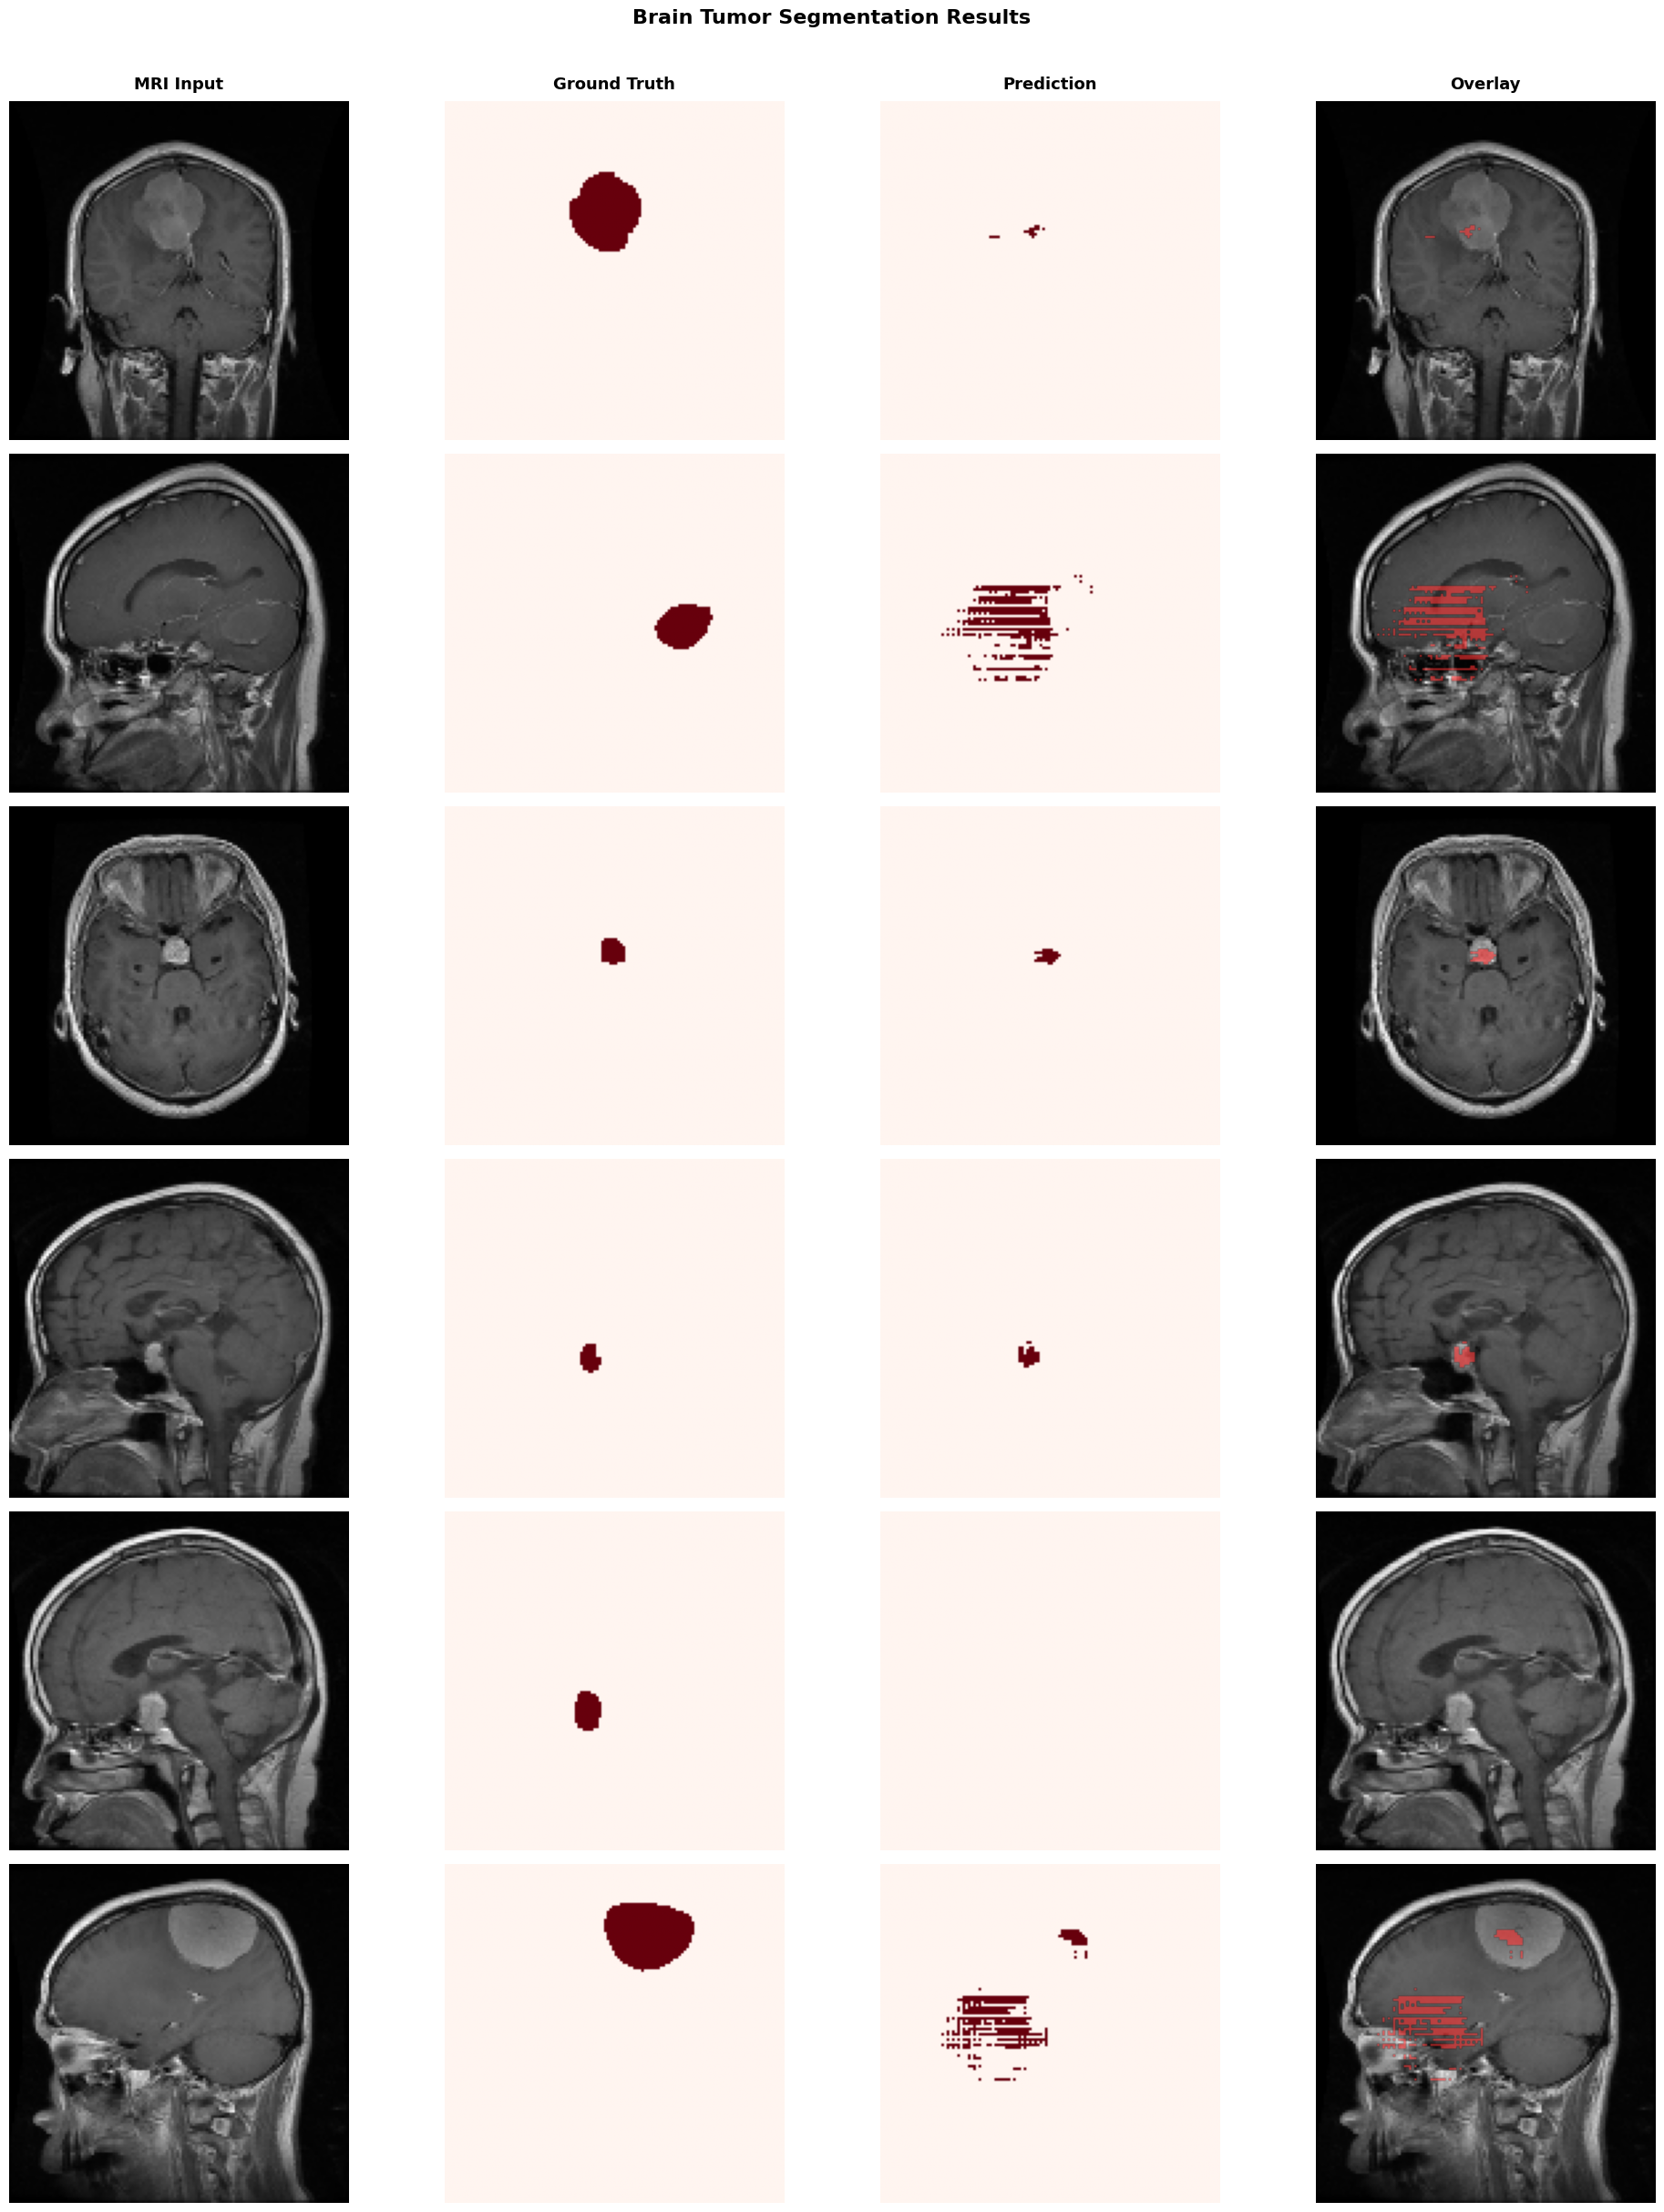

In [14]:
def visualize_predictions(model, dataset, num_samples=6, save=True):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, num_samples * 4))
    col_titles = ['MRI Input', 'Ground Truth', 'Prediction', 'Overlay']

    for col_idx, title in enumerate(col_titles):
        axes[0][col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)

    for row, idx in enumerate(indices):
        img, true_mask = dataset[idx]

        with torch.no_grad():
            pred       = model(img.unsqueeze(0).to(device))
            pred_mask  = pred.argmax(dim=1).squeeze().cpu().numpy()

        img_np  = img.squeeze().numpy()
        true_np = true_mask.numpy()

        # Red overlay for tumor
        overlay = np.zeros((*pred_mask.shape, 4), dtype=np.float32)
        overlay[pred_mask == 1] = [1.0, 0.2, 0.2, 0.6]

        axes[row][0].imshow(img_np,    cmap='gray')
        axes[row][1].imshow(true_np,   cmap='Reds', vmin=0, vmax=1)
        axes[row][2].imshow(pred_mask, cmap='Reds', vmin=0, vmax=1)
        axes[row][3].imshow(img_np,    cmap='gray')
        axes[row][3].imshow(overlay)

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle('Brain Tumor Segmentation Results',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save:
        os.makedirs('outputs/predictions', exist_ok=True)
        plt.savefig('outputs/predictions/results.png',
                    dpi=150, bbox_inches='tight')
        print("✅ Saved to outputs/predictions/results.png")

    plt.show()

# Run it
visualize_predictions(model, test_dataset, num_samples=6)